In [2]:
import matplotlib.pyplot as plt
import numpy as np

In [3]:
from lsst.daf.butler import Butler

In [66]:
from importlib import reload
import PSFtools
reload(PSFtools)

<module 'PSFtools' from '/home/i/ivezic/WORK/PSF/ZI-PSFanalysis/PSFtools.py'>

In [16]:
%matplotlib inline

In [4]:
butler = Butler('embargo', collections=['LSSTCam/runs/nightlyValidation'])

In [47]:
day_obs = 20260406
detectorID=1

In [8]:
condition = f"day_obs={day_obs} AND detector={detector}"
visitimage_refs = butler.query_datasets('preliminary_visit_image', 
                                        where=condition,
                                        order_by=['visit', 'detector'],
                                        with_dimension_records=True,
                                        limit=2000)
len(visitimage_refs)

614

In [9]:
visits = []
for ref in visitimage_refs:
    visit = ref.dataId["visit"]
    visits.append(visit)
len(visits)

614

0  from: 0 1 visitID= 2026040600018


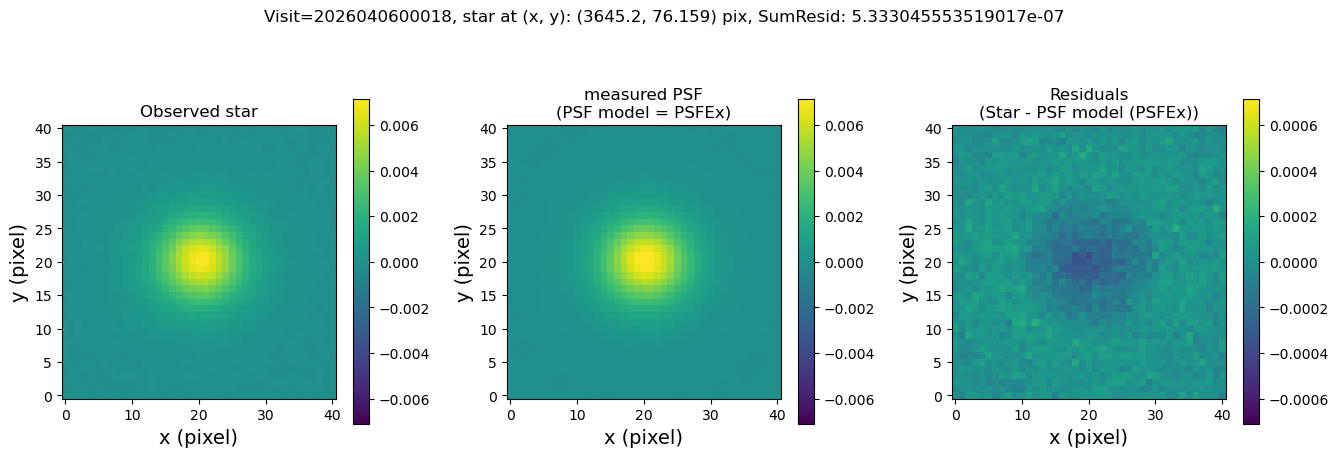

0  from: 0 1 visitID= 2026040600019


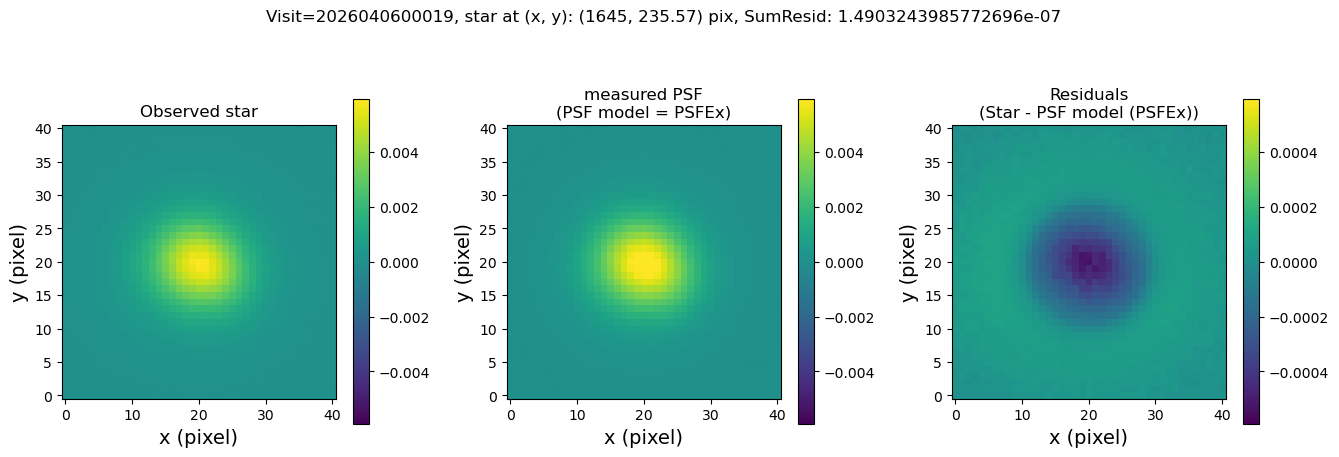

0  from: 0 1 visitID= 2026040600020


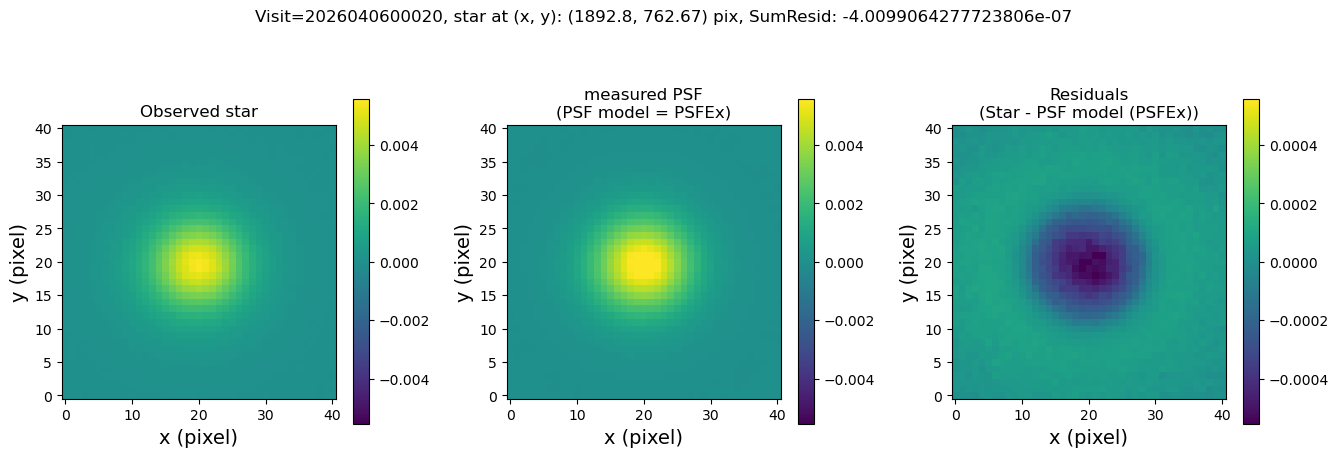

In [68]:
# 3 visits, 1 star per visit
starIndexMin = 0
starIndexMax = 1
# for visitIndex in range(0,len(visits)-1): 
for visitIndex in range(10,13): 
    psfTools.plotStarWithPSF(butler, visits, visitIndex, visitimage_refs, detectorID, starIndexMin, starIndexMax)

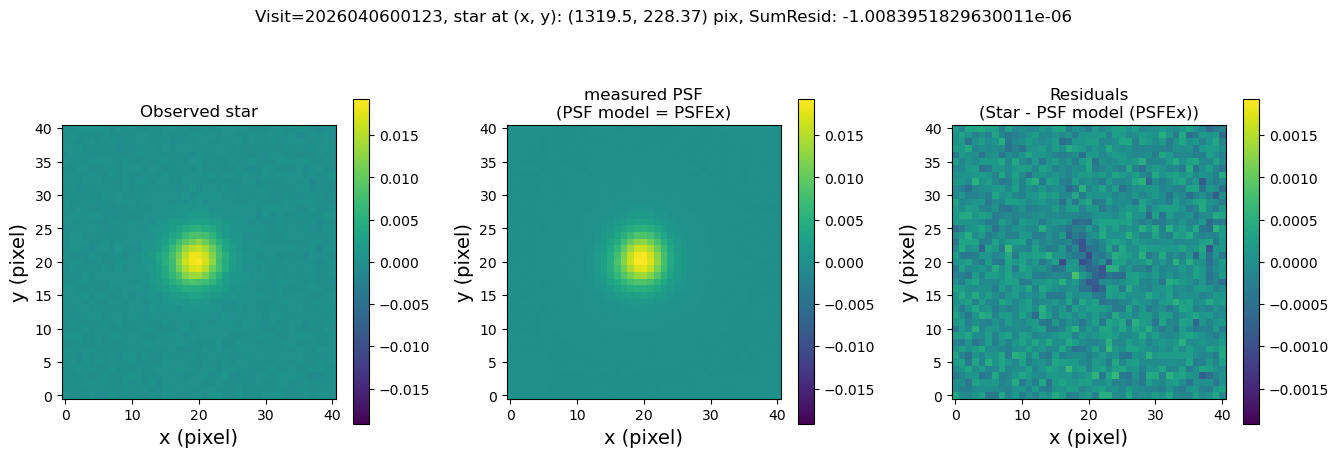

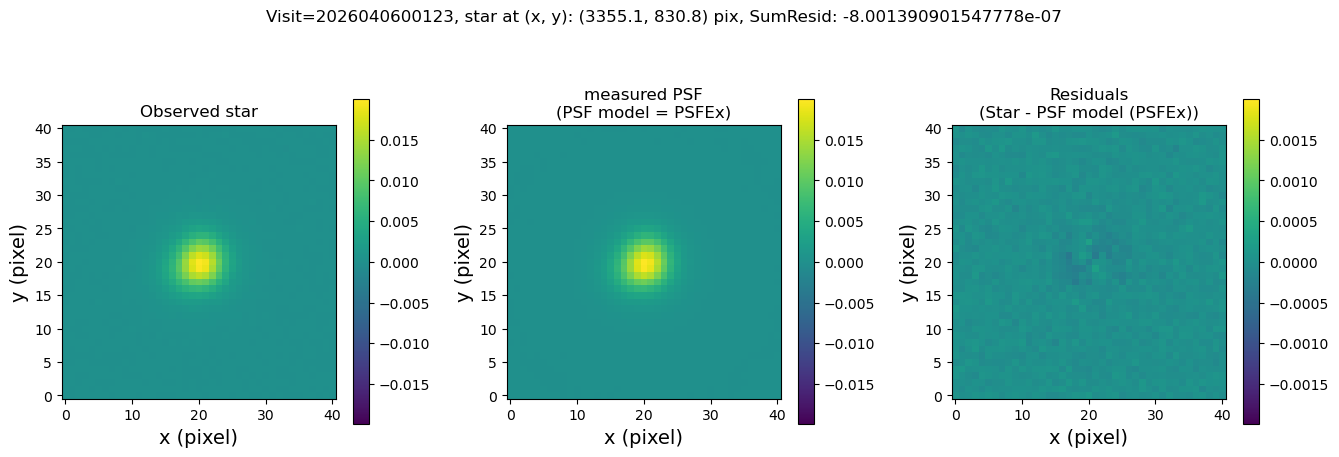

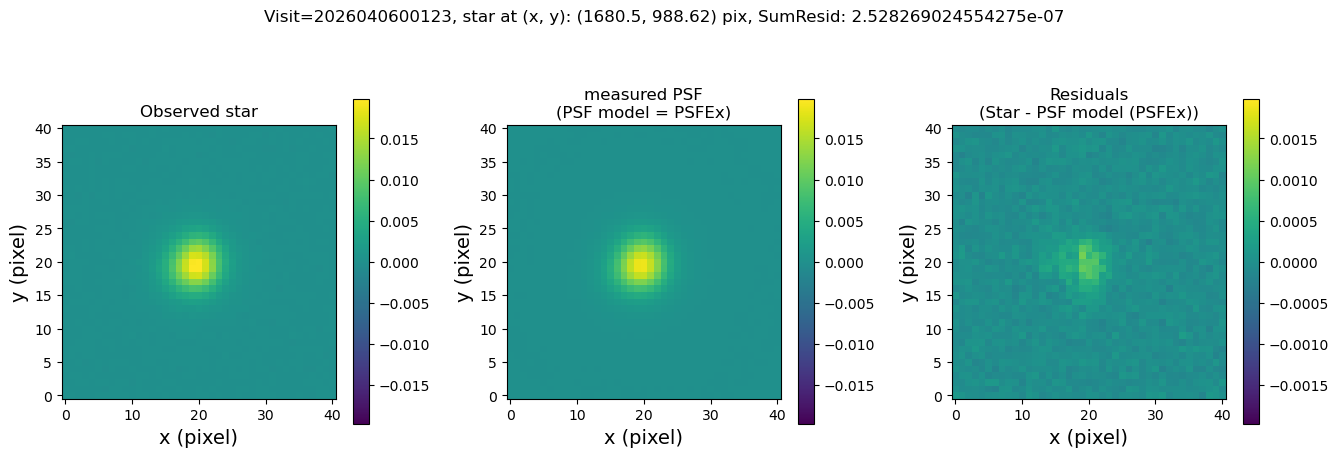

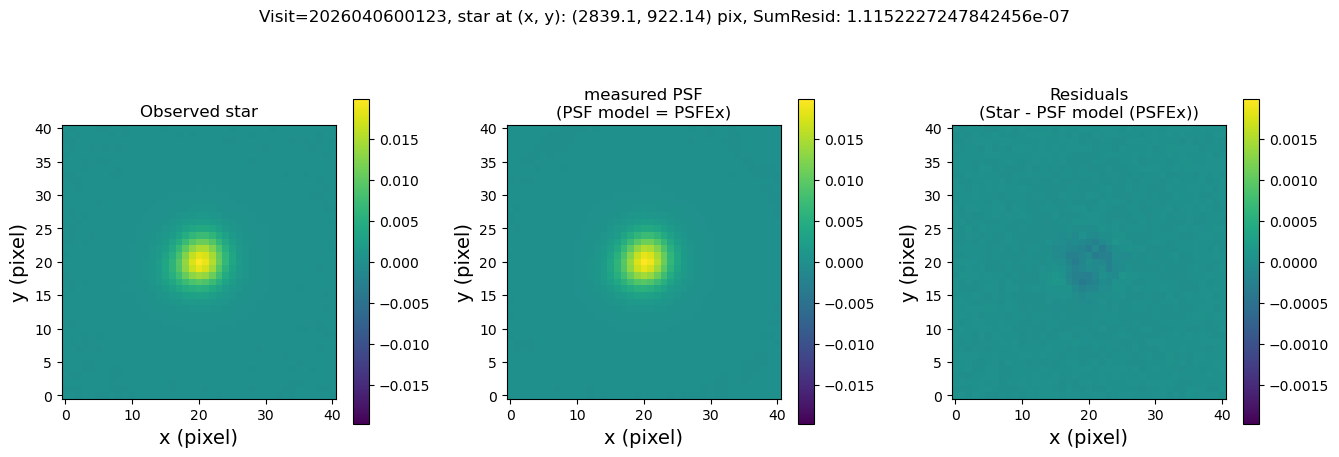

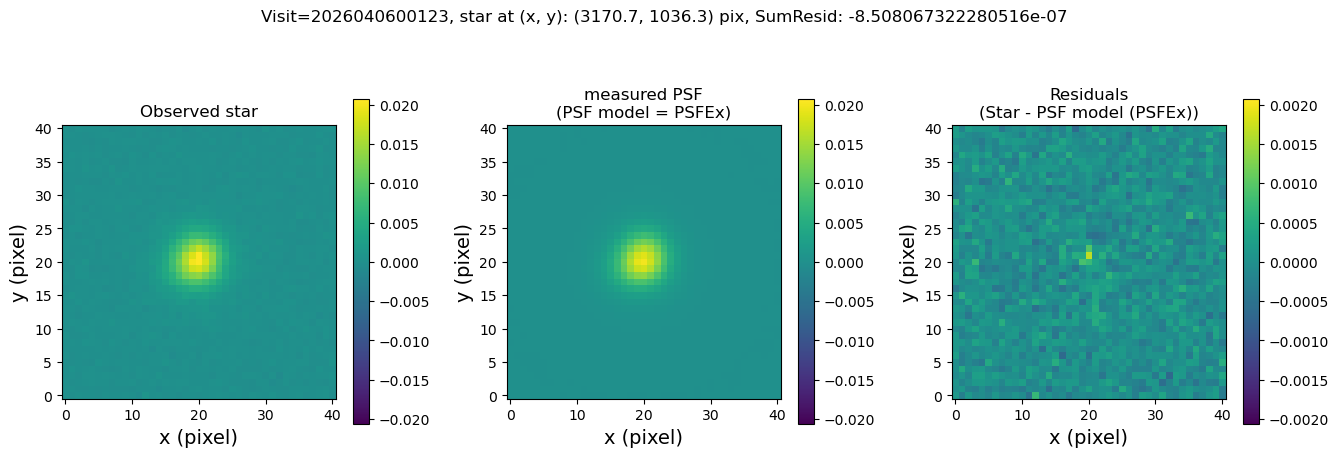

In [63]:
# 5 stars from the same visit and detector: GOOD stars (i.e. good visit)
for visitIndex in range(100,101): 
    psfTools.plotStarWithPSF(butler, visits, visitIndex, visitimage_refs, detectorID, 0, 5)

0  from: 0 5 visitID= 2026040600010


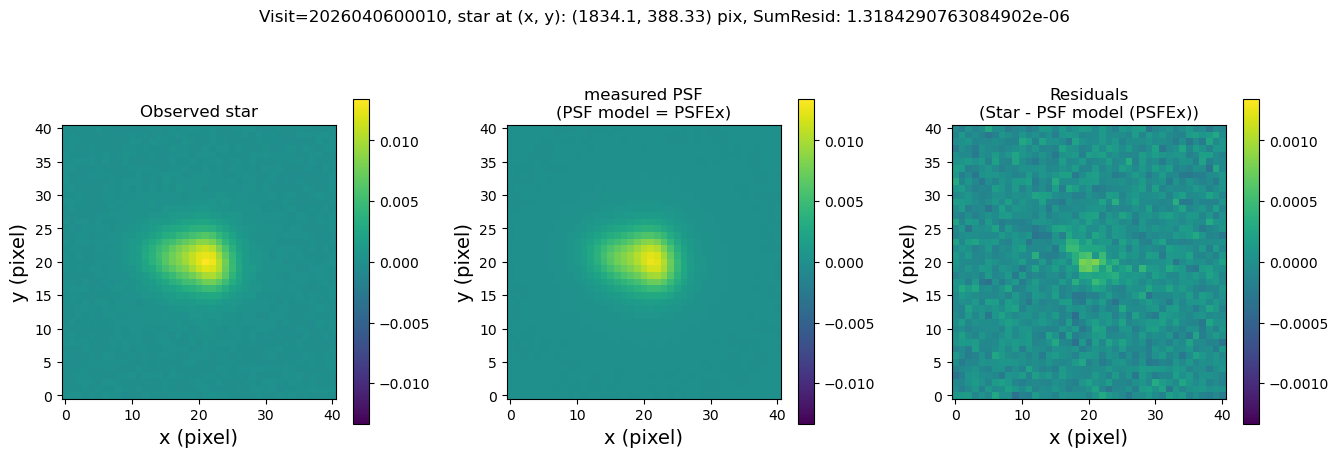

1  from: 0 5 visitID= 2026040600010


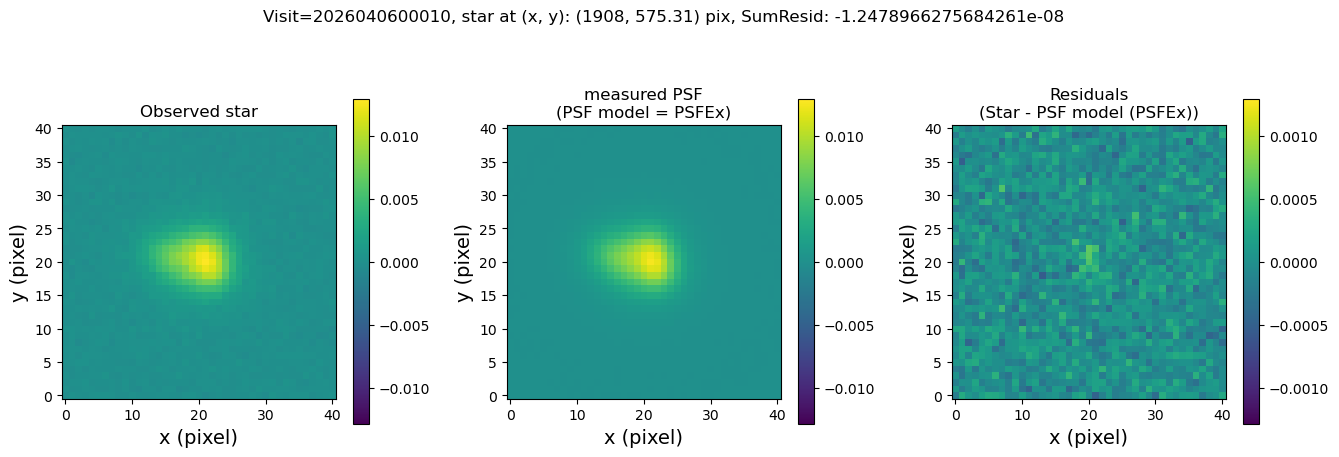

2  from: 0 5 visitID= 2026040600010


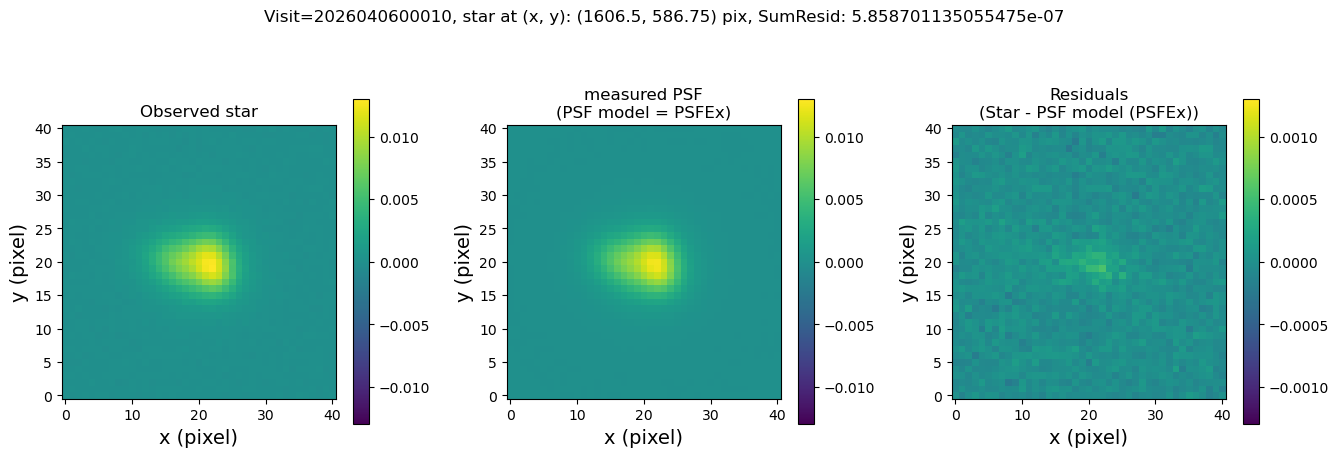

3  from: 0 5 visitID= 2026040600010


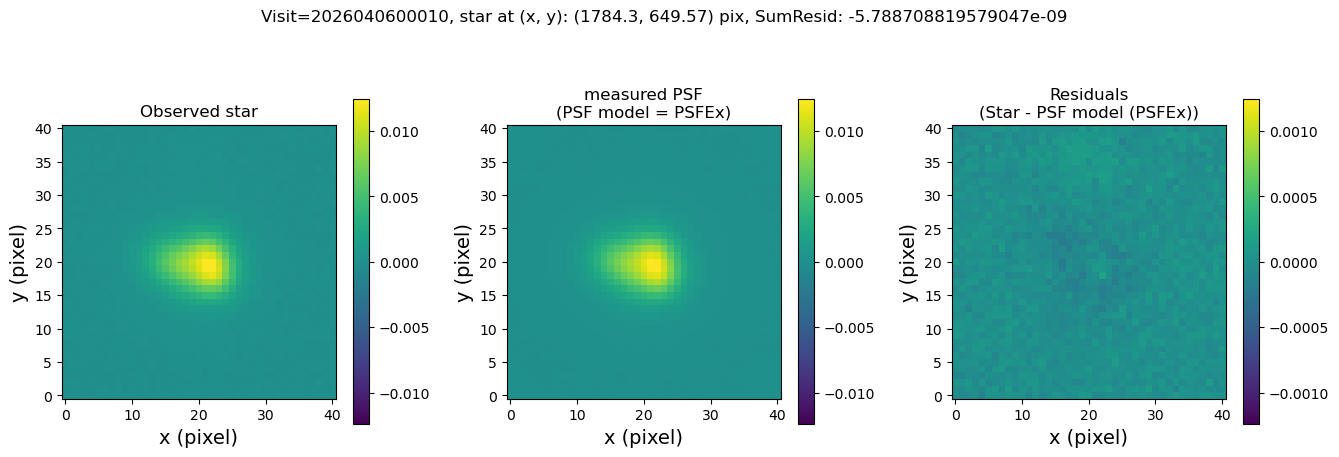

4  from: 0 5 visitID= 2026040600010


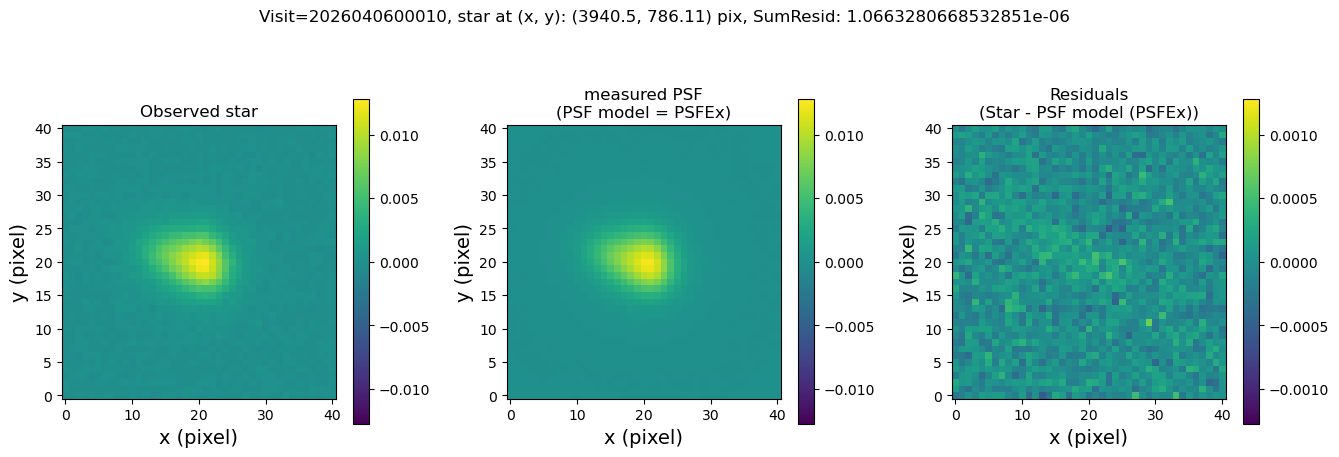

In [69]:
# stars from the same visit and detector (BAD stars)
for visitIndex in range(2,3): 
    psfTools.plotStarWithPSF(butler, visits, visitIndex, visitimage_refs, detectorID, 0, 5) 